In [156]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
df = pd.read_csv("./Data/city_day.csv")
print(df.head())
print()
print(f"Shape->{df.shape}")

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Shape->(29531, 16)


In [158]:
print(df['AQI_Bucket'].value_counts())

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [159]:
print(df.isnull().sum())

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [160]:
df=df.drop(columns=['City','Date'])
print(df.head())

   PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2      O3  Benzene  \
0    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64  133.36     0.00   
1    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   34.06     3.68   
2    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   30.70     6.80   
3    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   36.08     4.43   
4    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   39.31     7.01   

   Toluene  Xylene  AQI AQI_Bucket  
0     0.02    0.00  NaN        NaN  
1     5.50    3.77  NaN        NaN  
2    16.40    2.25  NaN        NaN  
3    10.14    1.00  NaN        NaN  
4    18.89    2.78  NaN        NaN  


In [161]:
df=df.dropna(subset=['AQI_Bucket'])
print(df.isnull().sum())  ## Reduction in Null values by removing empty rows

PM2.5           678
PM10           7086
NO              387
NO2             391
NOx            1857
NH3            6536
CO              445
SO2             605
O3              807
Benzene        3535
Toluene        5826
Xylene        15372
AQI               0
AQI_Bucket        0
dtype: int64


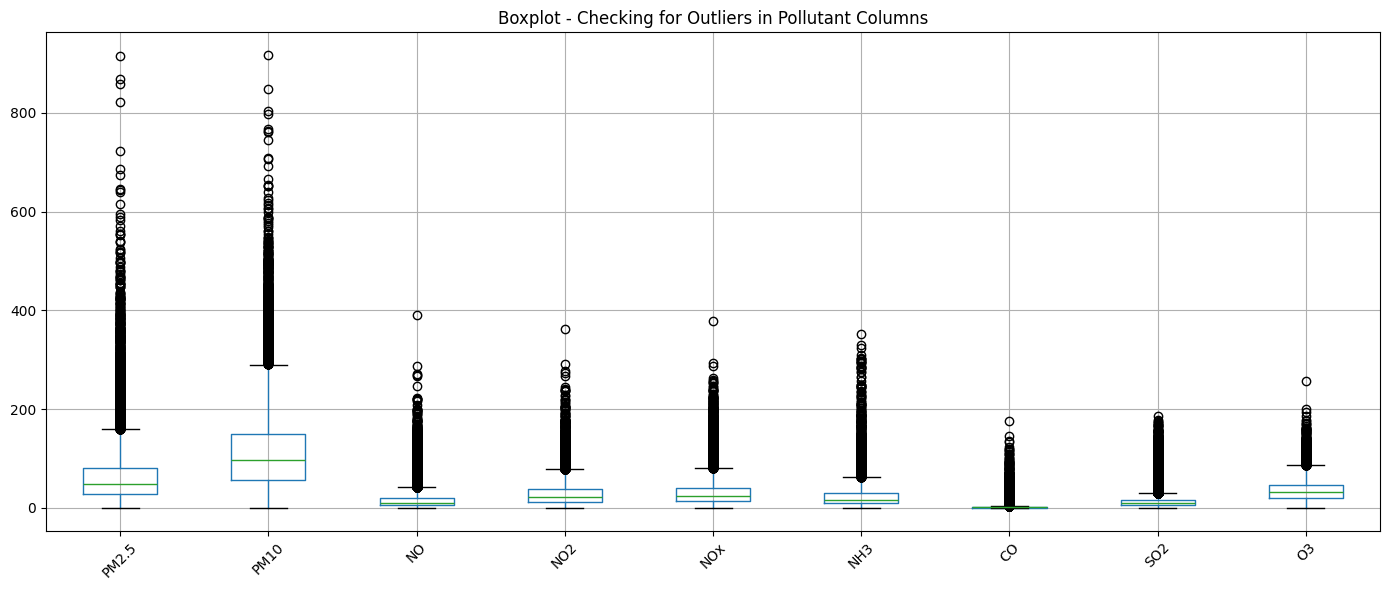

In [162]:
import matplotlib.pyplot as plt

# Boxplot for all pollutant columns
cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 
        'NH3', 'CO', 'SO2', 'O3']

plt.figure(figsize=(14, 6))
df[cols].boxplot()
plt.title('Boxplot - Checking for Outliers in Pollutant Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## From These Box Plots we can see that there are outliers in each feature (maybe dew to festivals like Diwai and maybe Forest Fire etc..)
## That means we have to fill the null values with the median value

In [163]:
df.fillna(df.median(numeric_only=True), inplace=True)
print("Shape-->",df.shape)
print("Total Null Values->",df.isnull().sum().sum())
print(df['AQI_Bucket'].value_counts())

Shape--> (24850, 14)
Total Null Values-> 0
AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [164]:
'Seprating Features and Targets'

X=df.drop(columns=['AQI','AQI_Bucket'])
y=df['AQI_Bucket']
print("Features:", X.columns.tolist())

Features: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']


In [165]:
le=LabelEncoder()
y_encoded=le.fit_transform(y)
print("Encoded sample", y_encoded)

Encoded sample [2 5 4 ... 3 3 0]


In [139]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled[0])

[ 0.25951827 -0.20862118 -0.47482081 -0.00655145  0.07001001 -0.24735826
  0.65727345  2.04735412  1.16782388 -0.2104929  -0.44085596  0.20753754]


In [140]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

In [ ]:
mlp=MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

In [147]:
mlp.fit(X_train,y_train)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [149]:
y_pred = mlp.predict(X_test)

In [154]:
print("Accuracy" ,accuracy_score(y_test,y_pred))

Accuracy 0.7921529175050301


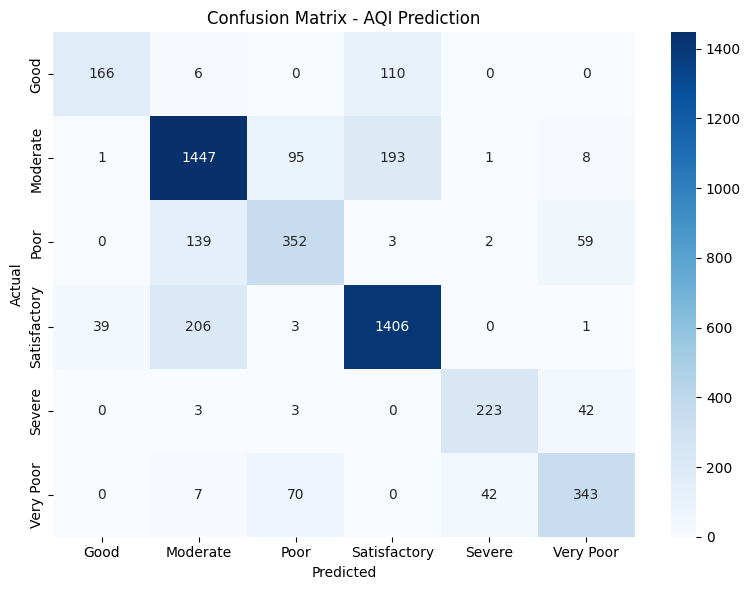

In [169]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - AQI Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## The model confidently predicts majority classes like Moderate and Satisfactory, but confuses neighboring categories like Good↔Satisfactory and Poor↔Very Poor due to their overlapping pollutant values and class imbalance, however it never confuses opposite extremes like Good and Severe proving it has correctly learned the overall air quality scale.